## Plot Results

This notebook is intended to generate plots and videos for the GP-MPC controller when you want to compare multiple log files against each other.

In [37]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd

# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [38]:
# Define some matplotlib parameters
# Use LaTeX for rendering text in plots
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

## Results: MPCC w/o knowledge, MPCC w/ knowledge, GP-MPC w/ linear kernel

Here we want to motivate the need for using a control method which can adapt to chaning model dynamics during runtime.
The MPCC without knowledge faills. The MPCC with knowledge works perfectly. The GP-MPCC gets very close to the latter in terms of performance.

In [39]:
# Load the necessary bags

# Create Logger object (needed to load data)
logger = Logger()

# Set names of the different logs
# The first set is for q_theta = 1e-2
filename1 = "2024-10-18_20-05-37" # MPCC w/o knowledge
filename2 = "2024-10-18_19-57-41" # MPCC w/ knowledge
filename3 = "2024-10-18_19-59-10" # GP-MPCC with linear kernel


filename1 = "2024-10-18_20-14-21" # MPCC w/o knowledge
filename2 = "2024-10-18_20-12-29" # MPCC w/ knowledge
filename3 = "2024-10-18_20-08-44" # GP-MPCC with linear kernel


filenames = [filename1, filename2, filename3]

# Load the pandas dataframes
df_list = []
for filename in filenames:
    df_list.append(logger.load_log(filename))

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-18_20-14-21
Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-18_20-12-29
Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-18_20-08-44


Let's compare the cumulative closed-loop cost of the three configurations.

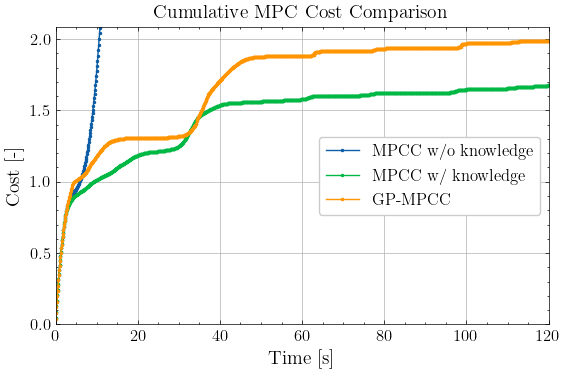

In [40]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['MPCC w/o knowledge', 'MPCC w/ knowledge', 'GP-MPCC']

# Iterate through each dataframe and plot the cumulative cost
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in 'mpc_cost' or 'Timestamp'
        df_clean = df[['Timestamp', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Compute cumulative cost
        df_clean['cumulative_cost'] = df_clean['mpc_cost'].cumsum()
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the cumulative cost with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['cumulative_cost'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Cost [-]')
plt.title('Cumulative MPC Cost Comparison')
plt.legend(loc='right', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=df_clean['cumulative_cost'].max()+ 0.1)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case1/case1_cumulative_cost.svg", format="svg")
plt.savefig("case1/case1_cumulative_cost.pdf", format="pdf")


In [41]:
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 80

# Define labels for each log file
labels = ['MPCC w/o knowledge', 'MPCC w/ knowledge', 'GP-MPCC']

# Initialize an empty list to store the results
results = []

# Iterate through each dataframe and compute the required metrics
for i, df in enumerate(df_list):
    if df is not None:
        # Drop rows with NaNs in the relevant columns
        df_clean = df[['Timestamp', 'tracking_error', 'attitude_error', 'mpc_cost']].dropna()
        
        # Optional modification to 'mpc_cost' if necessary
        df_clean['mpc_cost'] += 5e-2 * 0.2
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]
        
        # Calculate the metrics
        mean_tracking_error = df_clean['tracking_error'].mean()
        mean_attitude_error = df_clean['attitude_error'].mean()
        cumulative_mpc_cost = df_clean['mpc_cost'].cumsum().iloc[-1]  # Get final cumulative MPC cost
        
        # Append the results for this configuration
        results.append({
            'Configuration': labels[i],
            'Mean Tracking Error': mean_tracking_error,
            'Mean Attitude Error': mean_attitude_error,
            'Cumulative MPC Cost': cumulative_mpc_cost
        })

# Convert the results to a pandas DataFrame
comparison_df = pd.DataFrame(results)

# Display the table
print(comparison_df)

# Optionally, display the DataFrame as a LaTeX table
latex_table = comparison_df.to_latex(index=False, float_format="%.3f")
print(latex_table)

        Configuration  Mean Tracking Error  Mean Attitude Error  \
0  MPCC w/o knowledge             0.880820            93.781901   
1   MPCC w/ knowledge             0.061818            11.396573   
2             GP-MPCC             0.067184            11.922189   

      Cumulative MPC Cost  
0  [[117.69393163725343]]  
1  [[1.6205432832887168]]  
2  [[1.9330293038650117]]  
\begin{tabular}{lrrl}
\toprule
Configuration & Mean Tracking Error & Mean Attitude Error & Cumulative MPC Cost \\
\midrule
MPCC w/o knowledge & 0.881 & 93.782 & [[117.69393164]] \\
MPCC w/ knowledge & 0.062 & 11.397 & [[1.62054328]] \\
GP-MPCC & 0.067 & 11.922 & [[1.9330293]] \\
\bottomrule
\end{tabular}



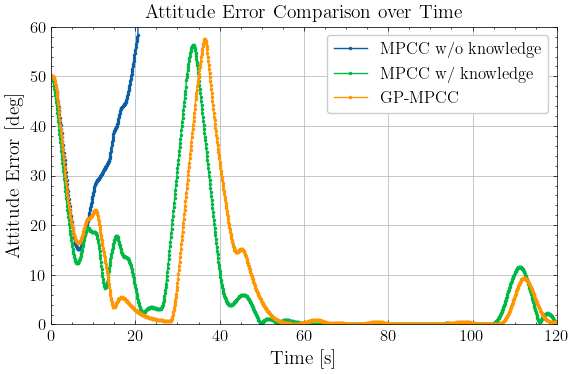

In [42]:
# %% [markdown]
# ## Compare Attitude Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['MPCC w/o knowledge', 'MPCC w/ knowledge', 'GP-MPCC']

# Iterate through each dataframe and plot the attitude error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'attitude_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'attitude_error']].dropna()

        if i == 0:
            END_TIME = 25
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the attitude error with the same style as your first notebook
        plt.plot(df_clean['Timestamp'], df_clean['attitude_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Attitude Error [deg]')
plt.title('Attitude Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim(bottom=0, top=60)

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case1/case1_attitude_error.svg", format="svg")
plt.savefig("case1/case1_attitude_error.pdf", format="pdf")


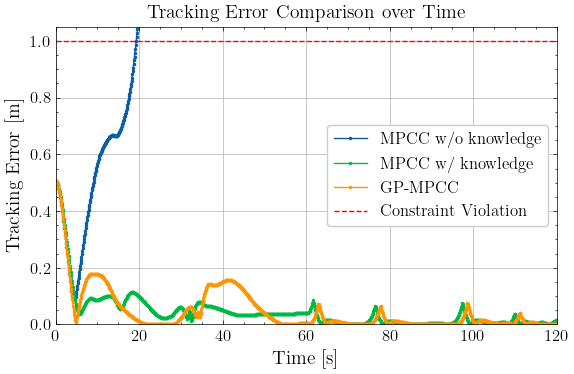

<Figure size 350x262.5 with 0 Axes>

In [43]:
# %% [markdown]
# ## Compare Tracking Error Over Time for Multiple Logs

# %%
# Specify parameters (adjust these if necessary)
START_TIME = 0
END_TIME = 120

# Create a figure for the comparison plot
plt.figure(figsize=(6,4))

# Define labels for each log file
labels = ['MPCC w/o knowledge', 'MPCC w/ knowledge', 'GP-MPCC']

# Iterate through each dataframe and plot the tracking error over time
for i, df in enumerate(df_list):
    START_TIME = 0
    END_TIME = 120
    if df is not None:
        # Drop rows with NaNs in 'tracking_error' or 'Timestamp'
        df_clean = df[['Timestamp', 'tracking_error']].dropna()

        if i==0:
            END_TIME = 21
        
        # Filter based on START_TIME and END_TIME
        if START_TIME is not None:
            df_clean = df_clean[df_clean['Timestamp'] >= START_TIME]
        if END_TIME is not None:
            max_timestamp = df_clean['Timestamp'].max()
            if END_TIME > max_timestamp:
                warnings.warn(f"Specified end_time {END_TIME} exceeds the maximum timestamp {max_timestamp}. Ignoring end_time filter.")
            else:
                df_clean = df_clean[df_clean['Timestamp'] <= END_TIME]

        # Plot the tracking error with the same style as your attitude error plot
        plt.plot(df_clean['Timestamp'], df_clean['tracking_error'], label=labels[i], marker='.', markersize=3, linewidth=1)

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=1, color='red', linestyle='--', label='Constraint Violation')

# Labels and title
plt.xlabel('Time [s]')
plt.ylabel('Tracking Error [m]')
plt.title('Tracking Error Comparison over Time')
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.grid(True)
plt.xlim((START_TIME, END_TIME))
plt.ylim((0, 1.05))

# Adjust layout to prevent label clipping
plt.tight_layout()

plt.savefig("case1/case1_tracking_error.svg", format="svg")
plt.savefig("case1/case1_tracking_error.pdf", format="pdf")